# Exploratory Data Analysis (EDA) — Tokyo 2020 Olympic Games

**Dataset yang digunakan:** `medals_total.csv` dari *Tokyo 2020 Olympic Games*.



## 1. Import Library

Library yang digunakan:
- **pandas** untuk membaca dan mengolah data.
- **numpy** untuk operasi numerik.
- **matplotlib** untuk membuat visualisasi.
- **seaborn** untuk membuat heatmap korelasi.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan tampilan angka agar lebih mudah dibaca
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 2. Membaca Dataset

Dataset yang digunakan adalah `medals_total.csv`. File ini berisi ringkasan perolehan medali negara pada Olimpiade Tokyo 2020.

Setiap baris merepresentasikan satu negara/entitas peserta, sedangkan kolom berisi peringkat dan jumlah medali emas, perak, perunggu, serta total medali.

In [18]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

Saving medals_total.csv to medals_total (1).csv


In [19]:
df = pd.read_csv('medals_total.csv')

# Menampilkan 5 data pertama
df.head()

,Rank,Country Code,Gold Medal,Silver Medal,Bronze Medal,Total,Country
0,1,USA,39,41,33,113,United States of America
1,2,CHN,38,32,18,88,People's Republic of China
2,3,JPN,27,14,17,58,Japan
3,4,GBR,22,21,22,65,Great Britain
4,5,ROC,20,28,23,71,ROC


## 3. Memahami Struktur Dataset

Pada tahap ini kita melihat ukuran dataset dan tipe data setiap attribute. Informasi ini membantu mengetahui berapa banyak record dan attribute yang tersedia serta membedakan data numerik dan kategorikal.

In [20]:
print("Ukuran dataset:", df.shape)
print("\nTipe data setiap attribute:")
print(df.dtypes)

print("\nInformasi dataset:")
df.info()

Ukuran dataset: (93, 7)

Tipe data setiap attribute:
Rank             int64
Country Code    object
Gold Medal       int64
Silver Medal     int64
Bronze Medal     int64
Total            int64
Country         object
dtype: object

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rank          93 non-null     int64 
 1   Country Code  93 non-null     object
 2   Gold Medal    93 non-null     int64 
 3   Silver Medal  93 non-null     int64 
 4   Bronze Medal  93 non-null     int64 
 5   Total         93 non-null     int64 
 6   Country       93 non-null     object
dtypes: int64(5), object(2)
memory usage: 5.2+ KB


## 4. Jumlah Record, Jumlah Attribute, Nama Attribute, dan Attribute Numerik

Sesuai instruksi Posttest 1, kita menampilkan:
- jumlah record/baris,
- jumlah attribute/kolom,
- nama seluruh attribute,
- jumlah attribute yang bertipe angka.

`select_dtypes(include='number')` digunakan untuk memilih kolom numerik secara otomatis.

In [21]:
jumlah_record = df.shape[0]
jumlah_attribute = df.shape[1]
nama_attribute = df.columns.tolist()
numeric_columns = df.select_dtypes(include='number').columns.tolist()

print("Jumlah record       :", jumlah_record)
print("Jumlah attribute    :", jumlah_attribute)
print("Nama attribute      :", nama_attribute)
print("Jumlah attribute angka:", len(numeric_columns))
print("\nAttribute bertipe angka:")
print(numeric_columns)

Jumlah record       : 93
Jumlah attribute    : 7
Nama attribute      : ['Rank', 'Country Code', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total', 'Country']
Jumlah attribute angka: 5

Attribute bertipe angka:
['Rank', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']


### Ringkasan Struktur Dataset

Dataset `medals_total.csv` memiliki **93 record dan 7 attribute**. Terdapat **5 attribute numerik** dan **2 attribute bertipe object**.

Attribute numerik digunakan untuk analisis statistik dan korelasi, sedangkan attribute object digunakan untuk melihat jumlah label/kategori.

## 5. Menampilkan 10 Record Pertama dari Attribute Bertipe Angka

Bagian ini memenuhi kriteria nomor 2. Hanya attribute numerik yang ditampilkan agar fokus pada data yang dapat dihitung secara statistik.

In [22]:
df[numeric_columns].head(10)

,Rank,Gold Medal,Silver Medal,Bronze Medal,Total
0,1,39,41,33,113
1,2,38,32,18,88
2,3,27,14,17,58
3,4,22,21,22,65
4,5,20,28,23,71
5,6,17,7,22,46
6,7,10,12,14,36
7,8,10,12,11,33
8,9,10,11,16,37
9,10,10,10,20,40


## 6. Statistik Deskriptif Attribute Numerik

Statistik deskriptif digunakan untuk memahami karakteristik data numerik.

Output `describe()` memuat:
- **mean** = rata-rata,
- **std** = standar deviasi,
- **min** = nilai minimum,
- **25%** = Q1,
- **50%** = Q2/median,
- **75%** = Q3,
- **max** = nilai maksimum.

In [23]:
statistik = df[numeric_columns].describe().T

# Mengganti nama agar lebih mudah dipahami
statistik = statistik.rename(columns={
    'mean': 'Rata-rata',
    'std': 'Standar Deviasi',
    'min': 'Minimum',
    '25%': 'Q1',
    '50%': 'Q2 (Median)',
    '75%': 'Q3',
    'max': 'Maksimum'
})

statistik

,count,Rata-rata,Standar Deviasi,Minimum,Q1,Q2 (Median),Q3,Maksimum
Rank,93.00,47.00,26.99,1.00,24.00,47.00,70.00,93.00
Gold Medal,93.00,3.66,7.02,0.00,0.00,1.00,3.00,39.00
Silver Medal,93.00,3.63,6.63,0.00,0.00,1.00,4.00,41.00
Bronze Medal,93.00,4.32,6.21,0.00,1.00,2.00,5.00,33.00
Total,93.00,11.61,19.09,1.00,2.00,4.00,11.00,113.00


## 7. Analisis Tambahan: Negara dengan Perolehan Medali Tertinggi

Untuk memperkaya eksplorasi, kita mencari 10 negara dengan jumlah total medali terbesar. Data diurutkan dari `Total` terbesar ke terkecil.

In [24]:
top10_total = df.sort_values(by='Total', ascending=False).head(10)
top10_total[['Rank', 'Country', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']]

,Rank,Country,Gold Medal,Silver Medal,Bronze Medal,Total
0,1,United States of America,39,41,33,113
1,2,People's Republic of China,38,32,18,88
4,5,ROC,20,28,23,71
3,4,Great Britain,22,21,22,65
2,3,Japan,27,14,17,58
5,6,Australia,17,7,22,46
9,10,Italy,10,10,20,40
8,9,Germany,10,11,16,37
6,7,Netherlands,10,12,14,36
7,8,France,10,12,11,33


## 8. Attribute Bertipe Object dan Jumlah Label

Attribute bertipe object pada dataset adalah `Country Code` dan `Country`.

`value_counts()` digunakan untuk menghitung berapa kali setiap label/kategori muncul pada masing-masing attribute object.

In [25]:
object_columns = df.select_dtypes(include='object').columns.tolist()

print("Attribute bertipe object:", object_columns)

for column in object_columns:
    print(f"\nJumlah label pada attribute '{column}':")
    print(df[column].value_counts())

Attribute bertipe object: ['Country Code', 'Country']

Jumlah label pada attribute 'Country Code':
Country Code
USA    1
CHN    1
JPN    1
GBR    1
ROC    1
      ..
GHA    1
GRN    1
KUW    1
MDA    1
SYR    1
Name: count, Length: 93, dtype: int64

Jumlah label pada attribute 'Country':
Country
United States of America      1
People's Republic of China    1
Japan                         1
Great Britain                 1
ROC                           1
                             ..
Ghana                         1
Grenada                       1
Kuwait                        1
Republic of Moldova           1
Syrian Arab Republic          1
Name: count, Length: 93, dtype: int64


### Ringkasan Attribute Object

`Country Code` dan `Country` berisi identitas negara/entitas peserta. Karena setiap negara/entitas muncul satu kali pada `medals_total.csv`, jumlah label unik pada kedua attribute tersebut sama dengan jumlah record, yaitu 93.

## 9. Pemeriksaan Missing Value

Pemeriksaan missing value merupakan eksplorasi tambahan untuk memastikan apakah terdapat data kosong yang dapat memengaruhi analisis.

In [26]:
missing = df.isnull().sum().to_frame('Jumlah Missing Value')
missing['Persentase (%)'] = (missing['Jumlah Missing Value'] / len(df) * 100).round(2)
missing

,Jumlah Missing Value,Persentase (%)
Rank,0,0.00
Country Code,0,0.00
Gold Medal,0,0.00
Silver Medal,0,0.00
Bronze Medal,0,0.00
Total,0,0.00
Country,0,0.00


### Interpretasi Missing Value

Jika seluruh nilai pada kolom **Jumlah Missing Value** adalah 0, berarti tidak terdapat data kosong pada dataset sehingga analisis dapat dilakukan tanpa proses imputasi missing value.

## 10. Visualisasi 1 — Bar Chart Top 10 Negara berdasarkan Total Medali

Bar chart dipilih karena cocok untuk membandingkan jumlah total medali antarnegara. Hanya 10 negara dengan total medali terbesar yang ditampilkan agar grafik mudah dibaca.

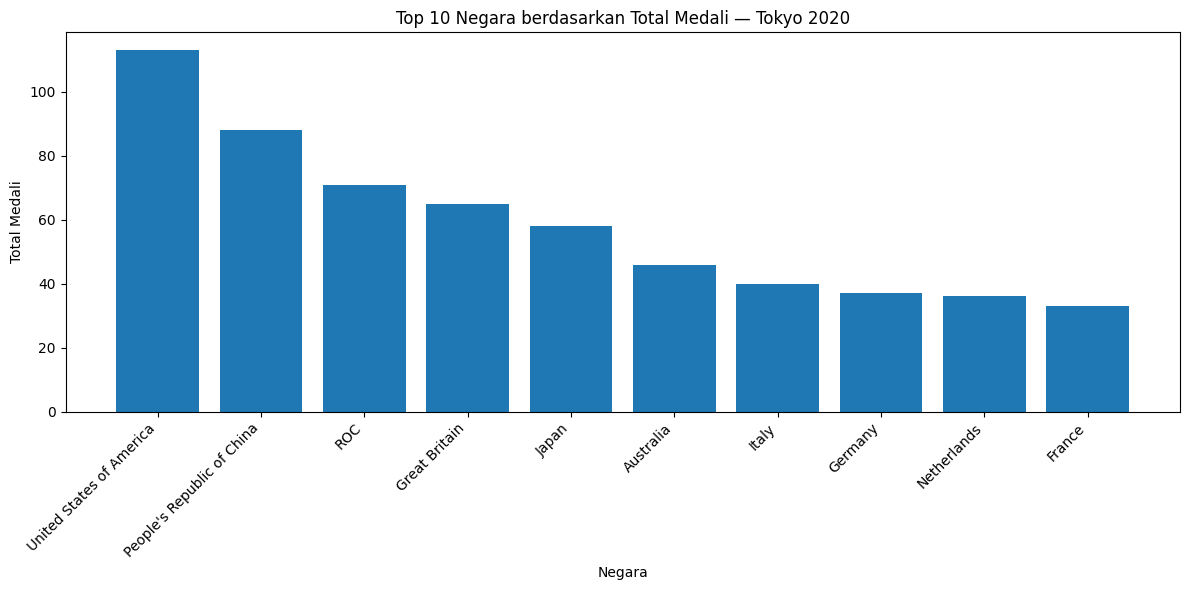

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(top10_total['Country'], top10_total['Total'])

plt.xlabel('Negara')
plt.ylabel('Total Medali')
plt.title('Top 10 Negara berdasarkan Total Medali — Tokyo 2020')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretasi Visualisasi 1

Grafik memperlihatkan perbandingan total medali pada 10 negara dengan perolehan medali terbesar. Negara dengan batang paling tinggi memiliki total medali paling banyak. Berdasarkan data, **United States of America** memiliki total medali paling tinggi, yaitu **113 medali**.

## 11. Visualisasi 2 — Perbandingan Gold, Silver, dan Bronze Medal

Grouped bar chart digunakan untuk membandingkan tiga jenis medali pada negara-negara dengan total medali terbesar. Grafik ini membantu melihat komposisi medali, bukan hanya jumlah totalnya.

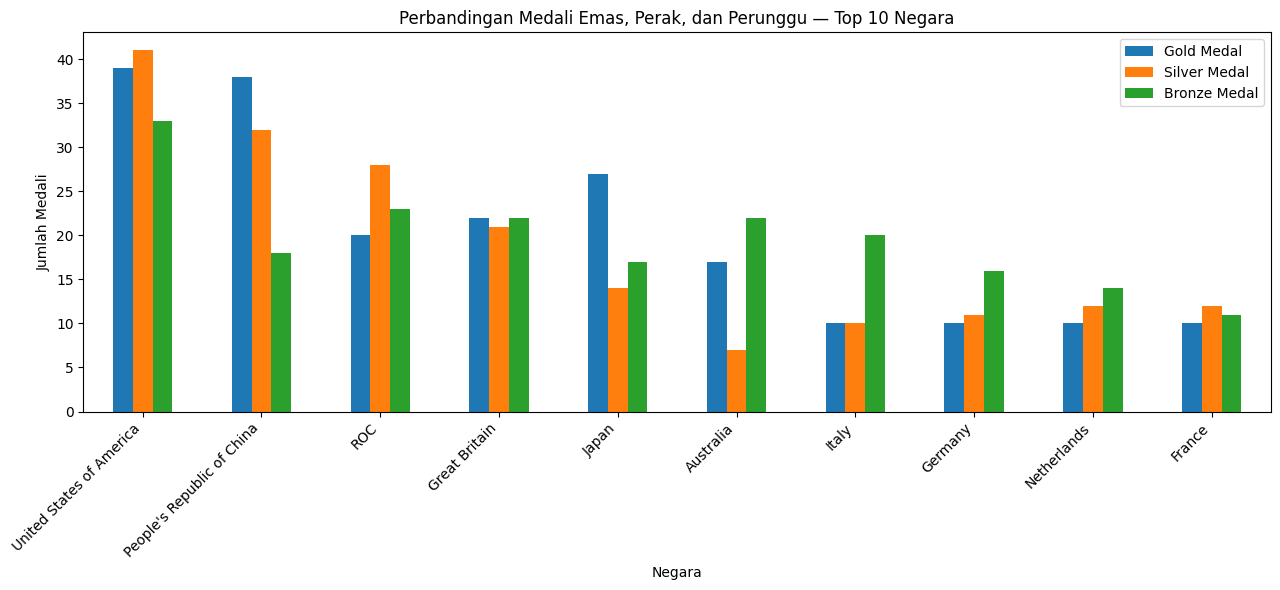

In [29]:
top10_medals = top10_total.set_index('Country')[[
    'Gold Medal', 'Silver Medal', 'Bronze Medal'
]]

ax = top10_medals.plot(kind='bar', figsize=(13, 6))

ax.set_xlabel('Negara')
ax.set_ylabel('Jumlah Medali')
ax.set_title('Perbandingan Medali Emas, Perak, dan Perunggu — Top 10 Negara')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretasi Visualisasi 2

Grouped bar chart memperlihatkan perbedaan jumlah medali emas, perak, dan perunggu pada setiap negara. Dengan grafik ini dapat diamati bahwa jumlah total medali suatu negara tidak selalu berasal dari satu jenis medali saja, tetapi merupakan gabungan dari ketiga jenis medali.

## 12. Analisis Korelasi Attribute Numerik

Korelasi digunakan untuk melihat arah dan kekuatan hubungan linear antarattribute numerik.

Nilai korelasi:
- mendekati **+1** → hubungan positif kuat,
- mendekati **0** → hubungan linear lemah/tidak ada,
- mendekati **-1** → hubungan negatif kuat.

Korelasi tidak berarti bahwa satu variabel menyebabkan variabel lainnya.

In [31]:
correlation = df[numeric_columns].corr()
correlation

,Rank,Gold Medal,Silver Medal,Bronze Medal,Total
Rank,1.00,-0.65,-0.59,-0.63,-0.65
Gold Medal,-0.65,1.00,0.93,0.86,0.97
Silver Medal,-0.59,0.93,1.00,0.86,0.97
Bronze Medal,-0.63,0.86,0.86,1.00,0.94
Total,-0.65,0.97,0.97,0.94,1.00


## 13. Heatmap Korelasi

Heatmap membuat matriks korelasi lebih mudah dibaca secara visual. `annot=True` menampilkan nilai korelasi pada setiap sel.

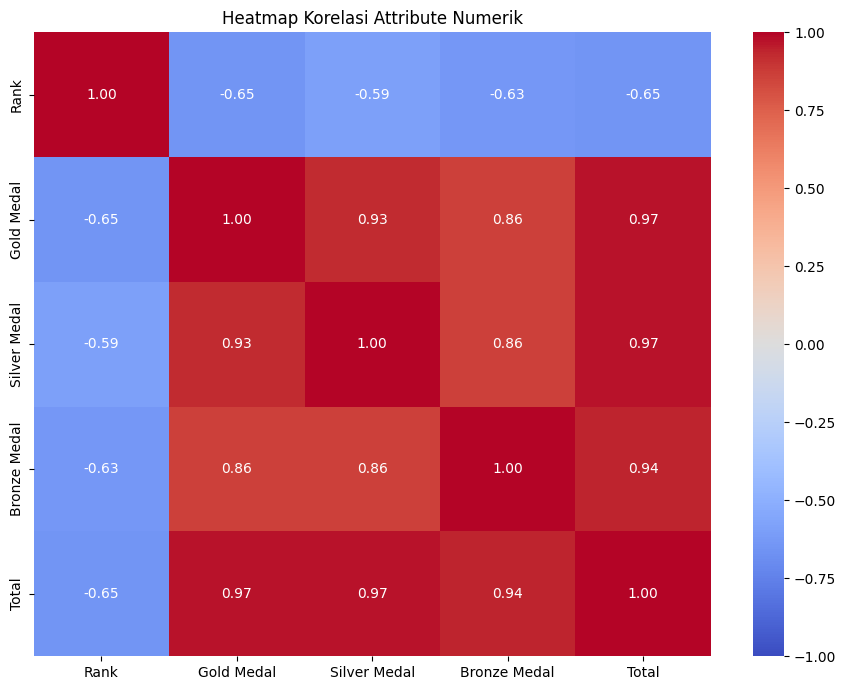

In [32]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Heatmap Korelasi Attribute Numerik')
plt.tight_layout()
plt.show()

### Interpretasi Heatmap

Korelasi antara **Gold Medal, Silver Medal, Bronze Medal, dan Total** cenderung positif karena `Total` merupakan jumlah dari ketiga jenis medali tersebut.

Sementara itu, `Rank` memiliki hubungan negatif dengan jumlah medali. Hal ini logis karena sistem peringkat menggunakan angka yang lebih kecil untuk posisi yang lebih tinggi. Dengan kata lain, negara dengan jumlah medali lebih banyak cenderung memiliki angka `Rank` yang lebih kecil.

## 14. Eksplorasi Tambahan — Negara dengan Medali Emas Terbanyak

Analisis ini digunakan untuk menemukan negara yang memiliki jumlah medali emas paling tinggi.

In [33]:
max_gold_index = df['Gold Medal'].idxmax()
df.loc[max_gold_index, ['Rank', 'Country', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']]

,0
Rank,1
Country,United States of America
Gold Medal,39
Silver Medal,41
Bronze Medal,33
Total,113


### Interpretasi

Hasil analisis menunjukkan negara dengan jumlah **medali emas terbanyak** pada dataset Tokyo 2020. Informasi ini dapat digunakan sebagai salah satu temuan utama dalam eksplorasi dataset.

## 15. Eksplorasi Tambahan — Rata-rata Perolehan Medali

Bagian ini membandingkan rata-rata jumlah medali emas, perak, perunggu, dan total dari seluruh negara/entitas dalam dataset.

In [34]:
mean_medals = df[['Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']].mean().sort_values(ascending=False)
mean_medals

,0
Total,11.61
Bronze Medal,4.32
Gold Medal,3.66
Silver Medal,3.63


## 16. Negara dengan Total Medali di Atas Rata-rata

Kita menghitung rata-rata `Total`, kemudian menampilkan negara yang memiliki total medali di atas nilai rata-rata tersebut.

In [35]:
rata_rata_total = df['Total'].mean()

di_atas_rata_rata = df[df['Total'] > rata_rata_total].sort_values(
    by='Total', ascending=False
)[['Rank', 'Country', 'Total']]

print(f"Rata-rata total medali: {rata_rata_total:.2f}")
di_atas_rata_rata

Rata-rata total medali: 11.61


,Rank,Country,Total
0,1,United States of America,113
1,2,People's Republic of China,88
4,5,ROC,71
3,4,Great Britain,65
2,3,Japan,58
5,6,Australia,46
9,10,Italy,40
8,9,Germany,37
6,7,Netherlands,36
7,8,France,33


## 17. Kesimpulan

Berdasarkan eksplorasi yang dilakukan, dapat disimpulkan bahwa:

1. Dataset `medals_total.csv` merupakan bagian dari dataset **Tokyo 2020 Olympic Games** yang berisi ringkasan perolehan medali negara/entitas.
2. Dataset memiliki **93 record dan 7 attribute**.
3. Terdapat **5 attribute numerik**, yaitu `Rank`, `Gold Medal`, `Silver Medal`, `Bronze Medal`, dan `Total`.
4. Terdapat **2 attribute object**, yaitu `Country Code` dan `Country`.
5. Statistik deskriptif digunakan untuk mengetahui rata-rata, standar deviasi, minimum, Q1, Q2, Q3, dan maksimum dari attribute numerik.
6. Bar chart menunjukkan negara dengan total medali terbanyak, sedangkan grouped bar chart memperlihatkan komposisi medali emas, perak, dan perunggu.
7. Heatmap menunjukkan hubungan antarattribute numerik. Hubungan antara jumlah medali dan `Total` sangat kuat dan positif karena `Total` merupakan hasil penjumlahan medali emas, perak, dan perunggu.
8. `Rank` cenderung berkorelasi negatif dengan jumlah medali karena angka peringkat yang lebih kecil menunjukkan posisi yang lebih tinggi.

